# Large-Scale Ternary Equilibrium: Al-Cu-Fe

A ternary system raises the cost per equilibrium point: more phases (14 here),
more sublattices, more degrees of freedom per phase. This notebook runs a
composition-composition-temperature grid — the workload behind isothermal
sections, liquidus projections, and solidification path studies.

As in the binary notebook, the grid is sized so the reference solver takes
roughly a minute.

In [1]:
import time
import warnings
import numpy as np
import matplotlib.pyplot as plt
import pycalphad
from pycalphad import Database, Workspace, calculate, equilibrium, variables as v

# The backend to demonstrate: 'c++' runs generated kernels on the CPU,
# 'gpu' runs the same kernels through CuPy on an NVIDIA or AMD GPU.
BACKEND = 'c++'

def timed(label, fn):
    """Run fn(), print and return (result, elapsed seconds)."""
    start = time.perf_counter()
    result = fn()
    elapsed = time.perf_counter() - start
    print(f'{label}: {elapsed:.1f} s')
    return result, elapsed


In [2]:
dbf = Database('../databases/Al-Cu-Fe.tdb')
comps = ['AL', 'CU', 'FE', 'VA']
phases = sorted(dbf.phases.keys())
nx, nt = 14, 48
conditions = {v.N: 1, v.P: 101325,
              v.X('AL'): (0.05, 0.85, 0.8 / (nx - 1)),
              v.X('CU'): (0.05, 0.85, 0.8 / (nx - 1)),
              v.T: (600, 1400.1, 800.0 / (nt - 1))}
print(f'{len(phases)} phases; grid = {nx} x {nx} compositions x {nt} temperatures '
      f'= {nx * nx * nt} conditions')
print('(compositions with X(AL)+X(CU) >= 1 are infeasible and are skipped by both solvers)')

21 phases; grid = 14 x 14 compositions x 48 temperatures = 9408 conditions
(compositions with X(AL)+X(CU) >= 1 are infeasible and are skipped by both solvers)


/mnt/c/users/scott/Documents/pycalphad/pycalphad/io/tdb.py:1017: UserWarning: The type definition character `W` was defined in the following phases: ['BCC_B2'], but no corresponding TYPE_DEFINITION line was found in the TDB.
  warnings.warn(f"The type definition character `{typechar}` was defined in the following phases: "
/mnt/c/users/scott/Documents/pycalphad/pycalphad/io/tdb.py:1017: UserWarning: The type definition character `M` was defined in the following phases: ['L12'], but no corresponding TYPE_DEFINITION line was found in the TDB.
  warnings.warn(f"The type definition character `{typechar}` was defined in the following phases: "


In [3]:
# Warm the kernel cache.
with pycalphad.backend(BACKEND):
    equilibrium(dbf, comps, phases, {v.N: 1, v.P: 101325, v.T: 1000,
                                     v.X('AL'): 0.2, v.X('CU'): 0.2});

## Reference solver (about a minute)

In [4]:
ref, t_ref = timed('reference solver   ', lambda: equilibrium(dbf, comps, phases, conditions))

reference solver   : 76.9 s


## Accelerated backend

In [5]:
with pycalphad.backend(BACKEND):
    acc, t_acc = timed('accelerated backend', lambda: equilibrium(dbf, comps, phases, conditions))

print(f'speedup: {t_ref / t_acc:.1f}x')

accelerated backend: 13.8 s
speedup: 5.6x


## Agreement

Alongside the energy comparison, note the convergence counts: conditions where
a solver failed to converge report NaN. (On this system the accelerated solver
typically converges at every point the reference does.)

In [6]:
def compare_results(ref, acc):
    """Agreement report between a reference and an accelerated result."""
    gm_ref = np.asarray(ref.GM.values, dtype=float).reshape(-1)
    gm_acc = np.asarray(acc.GM.values, dtype=float).reshape(-1)
    both = ~np.isnan(gm_ref) & ~np.isnan(gm_acc)
    print(f'conditions: {gm_ref.size}   converged: reference {int((~np.isnan(gm_ref)).sum())}, '
          f'accelerated {int((~np.isnan(gm_acc)).sum())}')
    dgm = np.abs(gm_acc[both] - gm_ref[both])
    print(f'max |dGM| over co-converged conditions: {dgm.max():.3e} J/mol '
          f'(relative: {(dgm / np.abs(gm_ref[both])).max():.3e})')
    ph_ref = np.asarray(ref.Phase.values).reshape(-1, ref.Phase.values.shape[-1])
    ph_acc = np.asarray(acc.Phase.values).reshape(-1, acc.Phase.values.shape[-1])
    mismatched = sum(sorted(p for p in ph_ref[i] if p) != sorted(p for p in ph_acc[i] if p)
                     for i in np.flatnonzero(both))
    print(f'stable-phase-set mismatches: {mismatched} of {int(both.sum())}')


In [7]:
compare_results(ref, acc)

conditions: 8112   converged: reference 5466, accelerated 5466
max |dGM| over co-converged conditions: 6.950e+01 J/mol (relative: 7.925e-04)
stable-phase-set mismatches: 4 of 5466


On this grid a handful of points (4 of 5,466 here) sit on a nearly degenerate
BCC_B2 miscibility-gap boundary where one and two composition sets of the same
phase differ by under a J/mol; the two implementations can resolve those points
differently (relative energy differences up to ~1e-3 at those points, numerical
precision everywhere else). The reference solver itself resolves them
differently between runs with different grid densities.

## An isothermal section from the accelerated grid

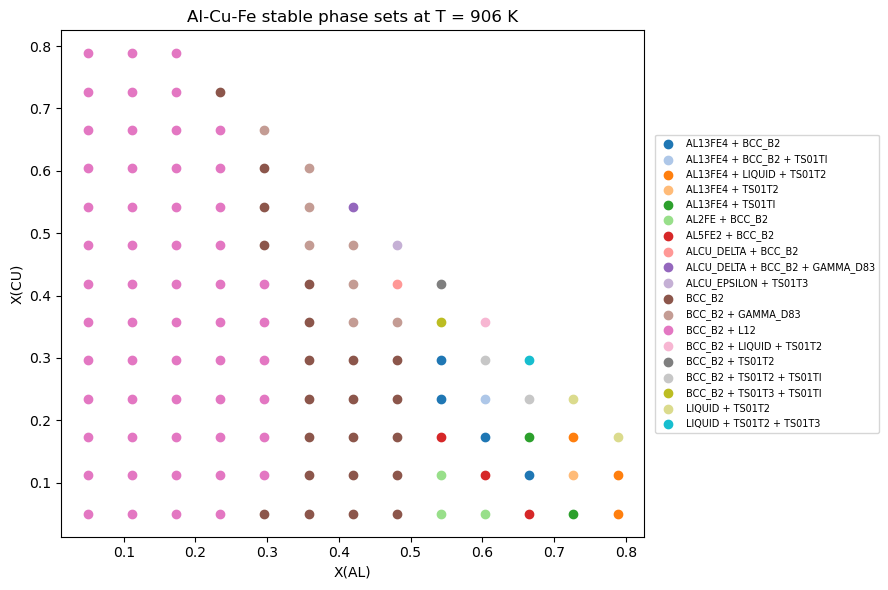

In [8]:
T_slice = 900.0
sl = acc.sel(T=T_slice, method='nearest')
ph = np.asarray(sl.Phase.values).squeeze()           # (X_AL, X_CU, vertex)
XA, XC = np.meshgrid(sl.coords['X_AL'].values, sl.coords['X_CU'].values, indexing='ij')
labels = np.array([' + '.join(sorted(set(row) - {''})) for row in ph.reshape(-1, ph.shape[-1])])

fig, ax = plt.subplots(figsize=(9, 6))
for i, lab in enumerate(sorted(set(labels) - {''})):
    m = labels == lab
    ax.scatter(XA.reshape(-1)[m], XC.reshape(-1)[m], s=36, label=lab,
               color=plt.cm.tab20(i % 20))
ax.set_xlabel('X(AL)'); ax.set_ylabel('X(CU)')
ax.set_title(f'Al-Cu-Fe stable phase sets at T = {float(sl.coords["T"].values):.0f} K')
ax.legend(loc='center left', bbox_to_anchor=(1.01, 0.5), fontsize=7)
plt.tight_layout()

For production-quality diagrams use the mapping notebook (**6**) — this scatter
is simply the raw grid, shown to make the point that a minute-scale reference
workload becomes interactive under the accelerated backend.